In [4]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage


In [5]:
model = ChatOllama(
    model="qwen3:4b",
    temperature=0,
)

## Model Defination 

In [6]:
from langchain_core.prompts import ChatPromptTemplate


generator_llm = ChatOllama(
    model="qwen3:4b",
    temperature=0.7,
)

generator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are Generator_11M.

Your responsibility is to generate high-quality candidate solutions.

Goals:
- Generate creative and diverse solutions.
- Explore multiple possible approaches.
- Do not spend excessive effort criticizing the solution.
- Prefer concrete, actionable outputs.
- Follow the user's constraints carefully.
- When appropriate, generate multiple alternatives.

You are a GENERATOR, not an evaluator.
Do not assign scores unless explicitly requested.
"""
    ),
    ("human", "{input}")
])

generator = generator_prompt | generator_llm

####################################################################
evaluator_llm = ChatOllama(
    model="qwen3:4b",
    temperature=0,
)

evaluator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are Evaluator_11M.

Your responsibility is to objectively evaluate candidate solutions.

Evaluate according to:
1. Correctness
2. Relevance
3. Completeness
4. Efficiency
5. Constraint compliance
6. Clarity
7. Robustness

Do not rewrite the entire solution unless explicitly requested.

Return your evaluation in this format:

SCORE: <0-10>

STRENGTHS:
- ...

WEAKNESSES:
- ...

CRITICAL_ISSUES:
- ...

IMPROVEMENTS:
- ...

FINAL_VERDICT:
<short explanation>

Be strict and objective.
Do not give a high score merely because the answer sounds convincing.
"""
    ),
    ("human", "{input}")
])

evaluator = evaluator_prompt | evaluator_llm


######################################################################
optimizer_llm = ChatOllama(
    model="qwen3:4b",
    temperature=0.2,
)

optimizer_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are Optimizer_11M.

Your responsibility is to improve an existing candidate solution
using evaluator feedback.

You must:

1. Preserve what already works.
2. Fix identified weaknesses.
3. Address critical issues first.
4. Respect the original requirements.
5. Avoid unnecessary changes.
6. Produce a concrete improved solution.

Do not blindly follow evaluator feedback if it is incorrect.
Use your own reasoning to determine whether the feedback is valid.

Return:

IMPROVED_SOLUTION:
<complete improved solution>

CHANGES_MADE:
- ...

REASONING:
- ...
"""
    ),
    ("human", """
ORIGINAL PROBLEM:
{problem}

CURRENT SOLUTION:
{solution}

EVALUATOR FEEDBACK:
{feedback}
""")
])

optimizer = optimizer_prompt | optimizer_llm

#### LLM Model Creation Done

# Conten Creation

In [7]:


class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")
    # score: int =Field(...,ge=0 ,le=5 ,description='Total score from the rubric (0 to 5).')


In [8]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [9]:
# state - tweet generated
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","need_improvement"]

    feedback:str
    iteration:int
    max_iterations:int



In [10]:
def generate_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send to generator
    response = generator_llm.invoke(messages).content

    # return the generated tweet
    return {'tweet':response}


In [11]:
from email import message
from pyexpat.errors import messages


def evaluate_tweet(state:TweetState):
    # prompt
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people retweet or share it?  
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """)
        ]   
    response = structured_evaluator_llm.invoke(messages)
    return  {'evaluation':response.evaluation, 'feedfack':response.feedback}


In [12]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)]

    response = optimizer_llm.invoke(message).content
    iteration = state['iteration']+1

    return {'tweet':response,'iteration':iteration}
    

In [13]:
def rotate_evaluation(state:TweetState):

    if state['evaluation']=='approved' or state['iteration']>= state['max_iterations']:
        return 'approved'
    else:
        return 'need_improvement'

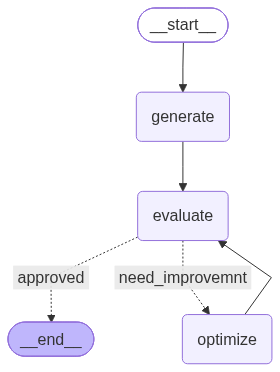

In [14]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')

graph.add_conditional_edges('evaluate',rotate_evaluation,{'approved':END, 'need_improvemnt':'optimize'})
graph.add_edge('optimize','evaluate')

workflow = graph.compile()
workflow

In [ ]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)


In [ ]:

result